Layoff Prediction Pipeline:
Binary classification: Did a company have layoffs(1 = yes, 0 = no)

Assumptions:
- All companies inside the CSV are positive (layoffs = 1)
- Negativ cases are synthetically generated at the ratio 1:1

Steps:
Load -> Synthetic negatives (for testing purpose /better with real data) -> Feature engineering -> Median Fill -> Train/Split -> 6 Models -> Evaluation

0. Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)
print('Imports Successfully!')

Imports Successfully!


1. Load Data 

In [ ]:
DATA_PATH = "../data/processed/merged_bs_cs_fd.csv"  # todo: put in config

df_pos = pd.read_csv(DATA_PATH)
df_pos['layoff'] = 1

META_COLS   = ['company', 'date', 'quarter', 'layoff'] # todo: put in config
FEATURE_COLS = [c for c in df_pos.columns if c not in META_COLS]

n_companies  = df_pos['company'].nunique()
n_rows_pos   = len(df_pos)

print(f'Positive companies : {n_companies}')
print(f'Positive rows      : {n_rows_pos}')
print(f'Feature columns    : {len(FEATURE_COLS)}')
print(f'Quarters present   : {sorted(df_pos["quarter"].unique())}')
df_pos.head(5)

Positive companies : 67
Positive rows      : 428
Feature columns    : 309
Quarters present   : ['2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1']


,company,date,quarter,bs_Minority Interest,bs_Other Equity Adjustments,bs_Capital Lease Obligations,bs_Other Current Liabilities,bs_Current Debt And Capital Lease Obligation,bs_Current Capital Lease Obligation,bs_Pensionand Other Post Retirement Benefit Plans Current,...,fin_Other Taxes,fin_Salaries And Wages,fin_Gain On Sale Of Ppe,fin_Securities Amortization,fin_Average Dilution Earnings,fin_Provision For Doubtful Accounts,fin_Net Income From Tax Loss Carryforward,fin_Preferred Stock Dividends,fin_Earnings From Equity Interest Net Of Tax,layoff
0,ANGI,2024-09-30,2024Q3,0.0,3278000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,ANGI,2024-12-31,2024Q4,0.0,NaN,12824000.0,69223000.0,12824000.0,12824000.0,57665000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,ANGI,2025-03-31,2025Q1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,ANGI,2025-06-30,2025Q2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,ANGI,2025-09-30,2025Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


2. Syncthetic Negative Generation

Strategy for each column we learn:
1. NaN probability from the real data (sparse columns stay sparse)
2. The empirical value distribution (bootstrap sampeling from observed non-NaN values)

In [77]:
def generate_synthetic_negatives(df_real, n_companies: int, random_state: int = 42) -> pd.DataFrame:
    """
    Generate synthetic negative (no-layoff) companies by:
    - Replicating the quarter structure of the real data
    - Per column: sampling observed non-NaN values (bootstrap) and
      reintroducing NaNs at the observed column-level NaN rate.
    """
    rng = np.random.default_rng(random_state)

    feat_cols = [c for c in df_real.columns if c not in ['company', 'date', 'quarter', 'layoff']]

    # Learn per-column stats from real data
    col_nan_rate   = {}  # probability a cell is NaN
    col_values     = {}  # pool of observed non-NaN values to resample from
    for col in feat_cols:
        observed = df_real[col].dropna().values
        col_nan_rate[col] = df_real[col].isnull().mean()
        col_values[col]   = observed if len(observed) > 0 else np.array([0.0])

    # Quarter/date structure to reuse (sample from real quarter sequences)
    quarter_sequences = (
        df_real.groupby('company')[['quarter', 'date']]
        .apply(lambda g: list(zip(g['quarter'], g['date'])))
        .tolist()
    )

    rows = []
    for i in range(n_companies):
        company_name = f'SYNTHETIC_NEG'
        # Pick a random real company's quarter sequence as template
        seq = quarter_sequences[rng.integers(len(quarter_sequences))]

        for quarter, date in seq:
            row = {'company': company_name, 'date': date, 'quarter': quarter, 'layoff': 0}
            for col in feat_cols:
                if rng.random() < col_nan_rate[col]:
                    row[col] = np.nan
                else:
                    row[col] = rng.choice(col_values[col])
            rows.append(row)

    return pd.DataFrame(rows)


df_neg = generate_synthetic_negatives(df_pos, n_companies=n_companies, random_state=RANDOM_STATE)

print(f'Synthetic negative rows : {len(df_neg)}')
print(f'Synthetic negative companies : {df_neg["company"].nunique()}')
print(f'NaN rate in synthetic data  : {df_neg[FEATURE_COLS].isnull().mean().mean():.2%}')
print(f'NaN rate in real data       : {df_pos[FEATURE_COLS].isnull().mean().mean():.2%}')

df_neg.head(5)

Synthetic negative rows : 433
Synthetic negative companies : 1
NaN rate in synthetic data  : 60.35%
NaN rate in real data       : 60.42%


,company,date,quarter,layoff,bs_Minority Interest,bs_Other Equity Adjustments,bs_Capital Lease Obligations,bs_Other Current Liabilities,bs_Current Debt And Capital Lease Obligation,bs_Current Capital Lease Obligation,...,fin_Gain On Sale Of Business,fin_Other Taxes,fin_Salaries And Wages,fin_Gain On Sale Of Ppe,fin_Securities Amortization,fin_Average Dilution Earnings,fin_Provision For Doubtful Accounts,fin_Net Income From Tax Loss Carryforward,fin_Preferred Stock Dividends,fin_Earnings From Equity Interest Net Of Tax
0,SYNTHETIC_NEG,2024-09-30,2024Q3,0,NaN,NaN,NaN,NaN,2.010000e+08,4826000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SYNTHETIC_NEG,2024-12-31,2024Q4,0,NaN,44000.0,60694000.0,NaN,2.374076e+08,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SYNTHETIC_NEG,2025-03-31,2025Q1,0,NaN,154000000.0,NaN,NaN,3.670000e+08,21900000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SYNTHETIC_NEG,2025-06-30,2025Q2,0,NaN,NaN,NaN,1.922490e+10,1.164200e+10,NaN,...,NaN,NaN,153000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SYNTHETIC_NEG,2025-09-30,2025Q3,0,NaN,NaN,408000000.0,NaN,4.125000e+06,11884000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


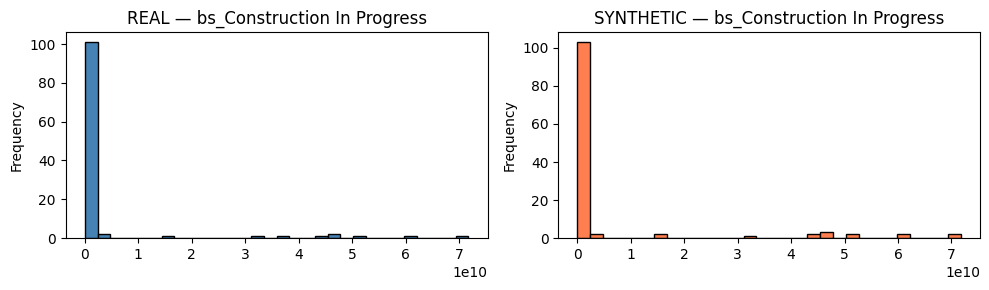

In [59]:
# Sanity check: compare value distributions for a sample column
sample_col = FEATURE_COLS[10]  # pick any column with decent coverage
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
df_pos[sample_col].dropna().plot(kind='hist', bins=30, ax=axes[0], title=f'REAL — {sample_col}', color='steelblue', edgecolor='black')
df_neg[sample_col].dropna().plot(kind='hist', bins=30, ax=axes[1], title=f'SYNTHETIC — {sample_col}', color='coral', edgecolor='black')
plt.tight_layout()
plt.show()

Combined dataset: (861, 313)
Label balance: {'No Layoff (0)': 433, 'Layoff (1)': 428}


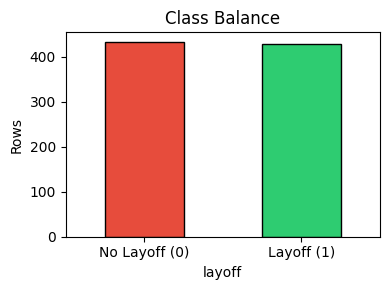

In [84]:
# Combine real positives + synthetic negatives
df_all = pd.concat([df_pos, df_neg], ignore_index=True)
print(f'Combined dataset: {df_all.shape}')
print(f'Label balance: {df_all["layoff"].value_counts().rename({1:"Layoff (1)", 0:"No Layoff (0)"}).to_dict()}')

fig, ax = plt.subplots(figsize=(4, 3))
df_all['layoff'].value_counts().rename({1:'Layoff (1)', 0:'No Layoff (0)'}).plot(
    kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
ax.set_title('Class Balance')
ax.set_ylabel('Rows')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

3. Feature Engineering
3.1 Boolean presence flags - NaN -> 0; any value (inc 0.0) -> 1:
why?:
Assuming a value is NaN, this might be because its just missing or there is some information that is usefull.

Capture when a metric reported at all. Keep seperate from numeric values

In [ ]:
presence_df = df_all[FEATURE_COLS].notna().astype(int)  # 1 if present, 0 if NaN
presence_df.columns = [f'HAS_{c}' for c in FEATURE_COLS]

# Drop zero-variance presence columns (allways 0 or 1)
# WHY? Because they don't provide any signal to distinguish between classes if they are always 0 or always 1.
pvar = presence_df.var()
presence_df = presence_df.loc[:, pvar > 0]
print(f"Presence features after removing zero variance: {presence_df.shape[1]} columns  ")

Presence features after removing zero variance: 309 columns  


3.2 Numeric features - fill NaN with column media
Attention: decision to choose Median is arbitrary, but i tought in the Moment is is reasonable


In [ ]:
numeric_df = df_all[FEATURE_COLS].copy()
col_medians = numeric_df.median()
numeric_df = numeric_df.fillna(col_medians)

# Drop any column still having all-NaN:
still_nan = numeric_df.columns[numeric_df.isnull().any()]
if len(still_nan) > 0:
    print(f"Dropping {len(still_nan)} columns with all-NaN values: {list(still_nan)}")
    numeric_df = numeric_df.drop(columns=still_nan)
# Do we need to drop HAS_ columns with all-NaN?
# No, they are binary indicators of presence, so they should not be dropped even if all 0 or 1 in one class.

# Drop zero variance numeric columns (constant value after median imputation)
nvar= numeric_df.var()
numeric_df = numeric_df.loc[:, nvar > 0]
print(f"Numeric features after removing zero variance: {numeric_df.shape[1]} columns  ")


Numeric features after removing zero variance: 303 columns  


3.3 Combine and verify:


In [63]:
x = pd.concat([numeric_df.reset_index(drop=True), presence_df.reset_index(drop=True)], axis=1)
y = df_all['layoff'].reset_index(drop=True)

assert x.isnull().sum().sum() == 0, "There should be no NaN values in the final feature set"
print(f'Final feature set shape: {x.shape}')
print(f'feature matrix : {y.value_counts().to_dict()}')
print(f'No NaN values')

Final feature set shape: (861, 612)
feature matrix : {0: 433, 1: 428}
No NaN values


4. Train / Test Split
Attention!: The synthetic negatives are generated from the same distribution as the positives. Therefore the model will liekly achieve higher accuracy partly because the synthetic data is easier to distinguish from a suble signal. Results here show can the model learn the pattern, but do not directly translate to real-world precision. Always validate on truely real companies when available.



In [64]:
# Stratified split — preserves 1:1 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale for distance/linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train label dist : {y_train.value_counts().to_dict()}')
print(f'Test  label dist : {y_test.value_counts().to_dict()}')

Train: 688 rows  |  Test: 173 rows
Train label dist : {0: 346, 1: 342}
Test  label dist : {0: 87, 1: 86}


5. Train & Evaluate all Models

In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# (name, model, use_scaled)
models = [
    ('Random Forest',      RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE), False),
    ('XGBoost',            XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0), False),
    ('Gradient Boosting',  GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    ('Logistic Regression',LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE), True),
    ('SVM',                SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE), True),
    ('KNN',                KNeighborsClassifier(n_neighbors=20), True),
]

results = []
for name, model, scaled in models:
    Xtr = X_train_sc if scaled else X_train
    Xte = X_test_sc  if scaled else X_test

    cv_auc = cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    lbl = str(int(y_test.unique()[0])) if y_test.nunique() == 1 else '1'
    pos_rep = rep.get('1', rep.get('1.0', {}))

    results.append({
        'Model':          name,
        'CV AUC':         f"{cv_auc.mean():.3f} ± {cv_auc.std():.3f}",
        'CV AUC mean':    cv_auc.mean(),
        'CV AUC std':     cv_auc.std(),
        'Test AUC':       test_auc,
        'Accuracy':       rep['accuracy'],
        'Precision (1)':  pos_rep.get('precision', 0),
        'Recall (1)':     pos_rep.get('recall', 0),
        'F1 (1)':         pos_rep.get('f1-score', 0),
        '_model': model, '_scaled': scaled, '_y_pred': y_pred, '_y_prob': y_prob
    })
    print(f'{name:25s}  CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}  |  Test AUC: {test_auc:.3f}  |  Acc: {rep["accuracy"]:.3f}')

print('All models done')

Random Forest              CV AUC: 1.000 ± 0.000  |  Test AUC: 1.000  |  Acc: 0.994
XGBoost                    CV AUC: 1.000 ± 0.000  |  Test AUC: 1.000  |  Acc: 0.994
Gradient Boosting          CV AUC: 1.000 ± 0.000  |  Test AUC: 1.000  |  Acc: 0.994
Logistic Regression        CV AUC: 0.532 ± 0.044  |  Test AUC: 0.370  |  Acc: 0.543
SVM                        CV AUC: 0.991 ± 0.005  |  Test AUC: 0.992  |  Acc: 0.902
KNN                        CV AUC: 0.488 ± 0.013  |  Test AUC: 0.452  |  Acc: 0.497
All models done


6. Results Summary

In [66]:
display_cols = ['Model','CV AUC','Test AUC','Accuracy','Precision (1)','Recall (1)','F1 (1)']
results_df = pd.DataFrame(results)[display_cols].sort_values('Test AUC', ascending=False).reset_index(drop=True)
print("Model Performance Summary:")
print(results_df.to_string(index=False))

Model Performance Summary:
              Model        CV AUC  Test AUC  Accuracy  Precision (1)  Recall (1)   F1 (1)
      Random Forest 1.000 ± 0.000  1.000000  0.994220       1.000000    0.988372 0.994152
            XGBoost 1.000 ± 0.000  1.000000  0.994220       0.988506    1.000000 0.994220
  Gradient Boosting 1.000 ± 0.000  1.000000  0.994220       0.988506    1.000000 0.994220
                SVM 0.991 ± 0.005  0.991981  0.901734       1.000000    0.802326 0.890323
                KNN 0.488 ± 0.013  0.451818  0.497110       0.497110    1.000000 0.664093
Logistic Regression 0.532 ± 0.044  0.370222  0.543353       0.527132    0.790698 0.632558


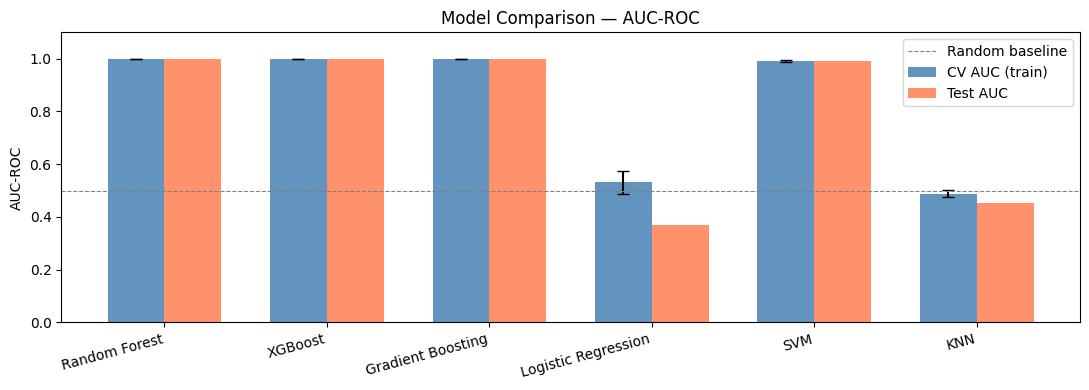

In [67]:
# Bar chart: CV AUC vs Test AUC
cv_means = [r['CV AUC mean'] for r in results]
cv_stds  = [r['CV AUC std']  for r in results]
test_aucs = [r['Test AUC']   for r in results]
names     = [r['Model']      for r in results]

x_plt = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x_plt - w/2, cv_means,  w, yerr=cv_stds, label='CV AUC (train)', color='steelblue', alpha=0.85, capsize=4)
ax.bar(x_plt + w/2, test_aucs, w, label='Test AUC', color='coral', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline')
ax.set_xticks(x_plt)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUC-ROC')
ax.set_title('Model Comparison — AUC-ROC')
ax.legend()
plt.tight_layout()
plt.show()

7. Confusion Matrices and ROC Curves

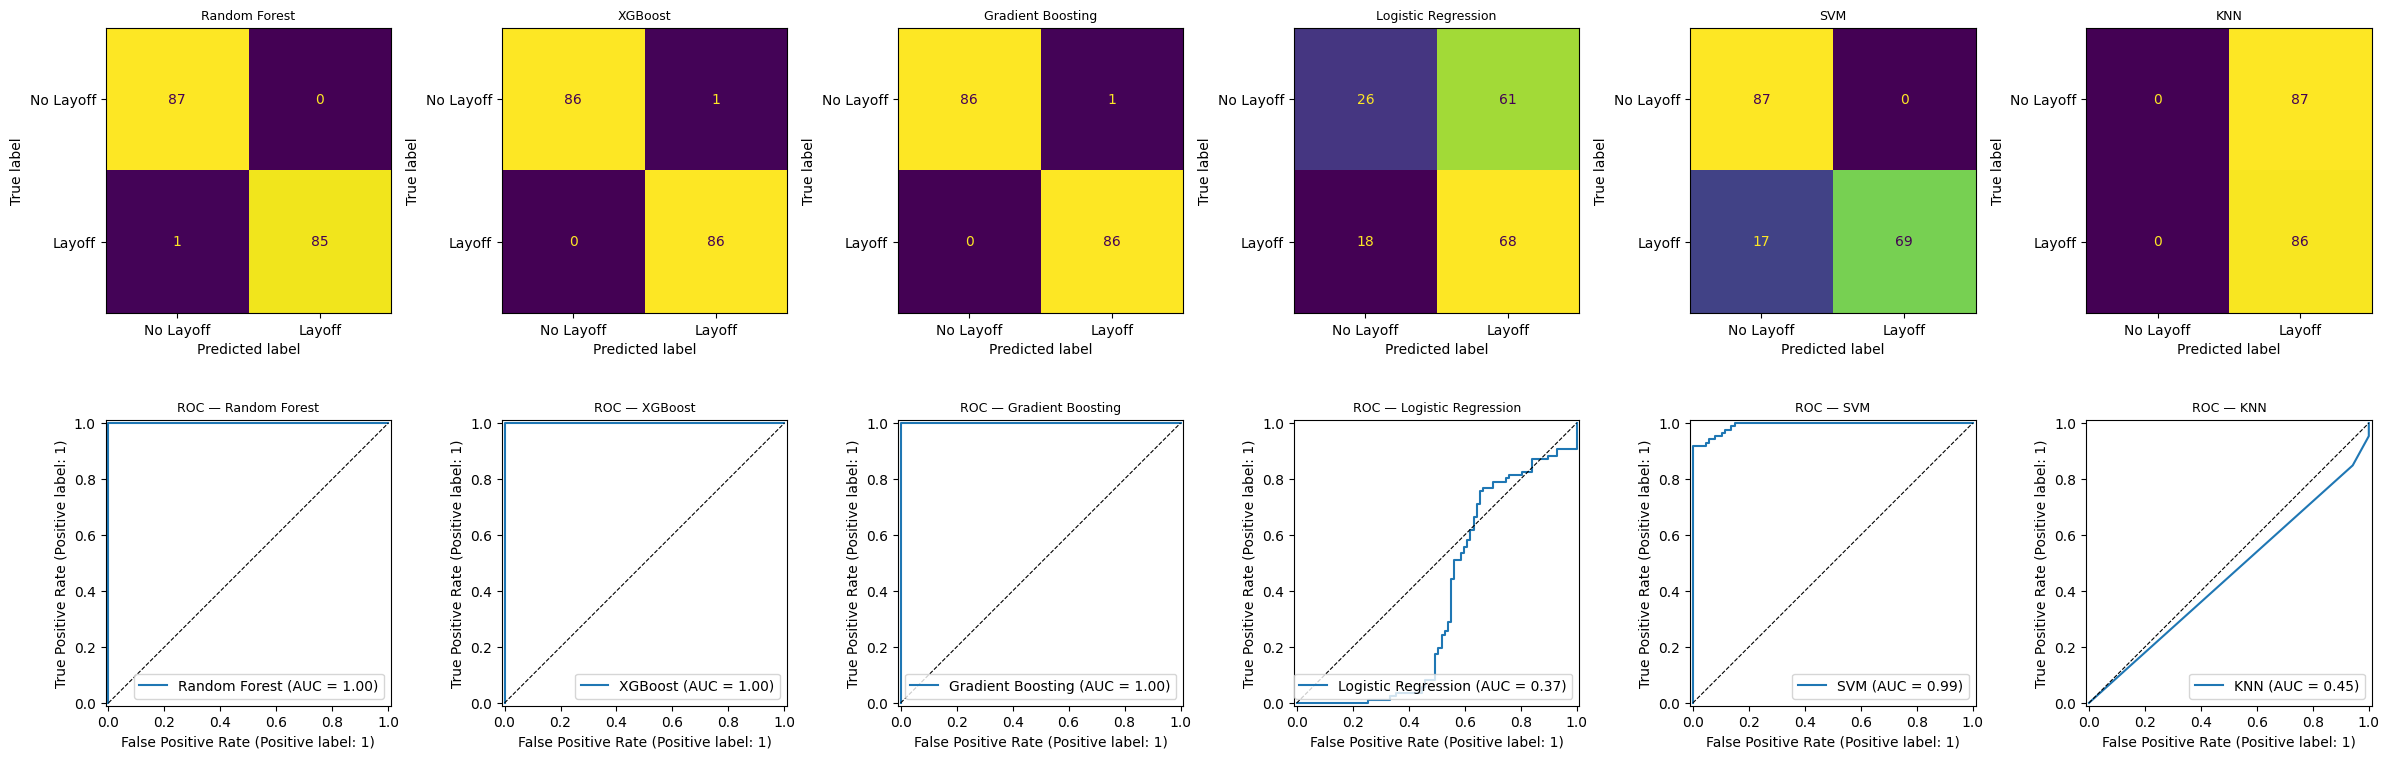

In [68]:
n = len(results)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
for i, r in enumerate(results):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, r['_y_pred']),
        display_labels=['No Layoff', 'Layoff']
    ).plot(ax=axes[0, i], colorbar=False)
    axes[0, i].set_title(r['Model'], fontsize=9)

    RocCurveDisplay.from_predictions(y_test, r['_y_prob'], ax=axes[1, i], name=r['Model'])
    axes[1, i].plot([0,1],[0,1],'k--',linewidth=0.8)
    axes[1, i].set_title('ROC — ' + r['Model'], fontsize=9)

plt.tight_layout()
plt.show()

8. Feature Importance (Best Tree Model)

Feature importance from: Random Forest (Test AUC = 1.000)


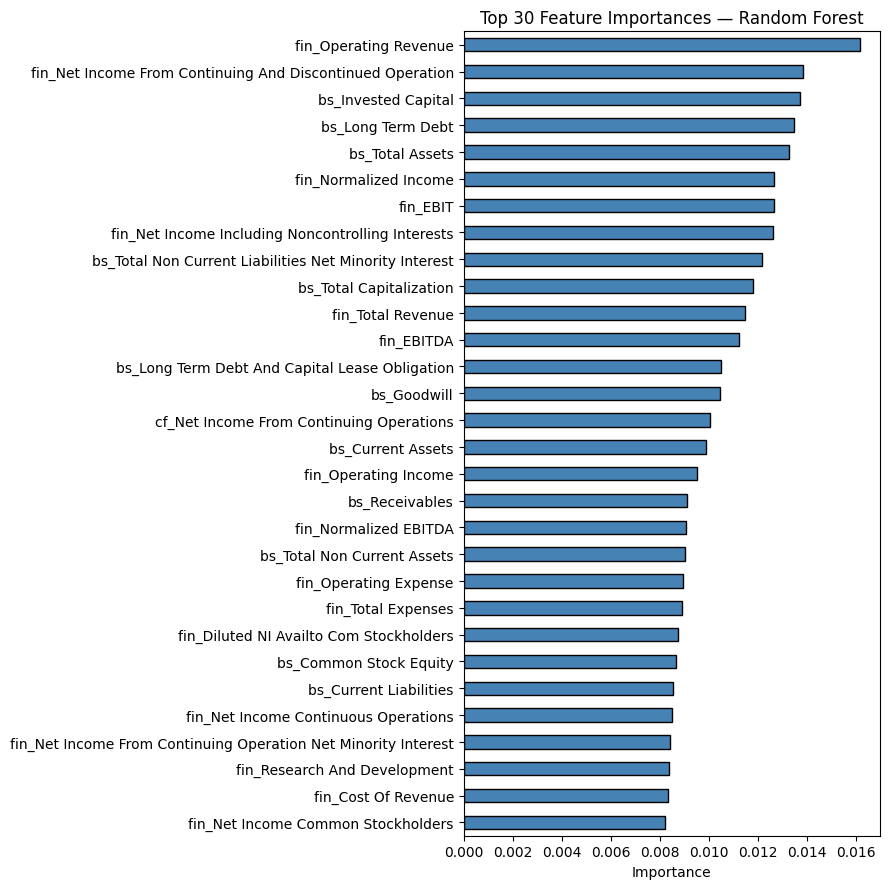

Top 20 features:
fin_Operating Revenue                                        0.016187
fin_Net Income From Continuing And Discontinued Operation    0.013847
bs_Invested Capital                                          0.013740
bs_Long Term Debt                                            0.013486
bs_Total Assets                                              0.013273
fin_Normalized Income                                        0.012689
fin_EBIT                                                     0.012673
fin_Net Income Including Noncontrolling Interests            0.012643
bs_Total Non Current Liabilities Net Minority Interest       0.012193
bs_Total Capitalization                                      0.011817
fin_Total Revenue                                            0.011477
fin_EBITDA                                                   0.011261
bs_Long Term Debt And Capital Lease Obligation               0.010508
bs_Goodwill                                                  0.010460
cf_

In [69]:
tree_results = [r for r in results if hasattr(r['_model'], 'feature_importances_')]
best = max(tree_results, key=lambda r: r['Test AUC'])
print(f'Feature importance from: {best["Model"]} (Test AUC = {best["Test AUC"]:.3f})')

importances = pd.Series(best['_model'].feature_importances_, index=X_train.columns)
top30 = importances.nlargest(30)

fig, ax = plt.subplots(figsize=(9, 9))
top30.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title(f'Top 30 Feature Importances — {best["Model"]}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 20 features:')
print(top30.head(20).to_string())

9. Full Classification Report (Best Model)

In [70]:
best_overall = max(results, key=lambda r: r['Test AUC'])
print(f'=== Best Model: {best_overall["Model"]} ===')
print(f'Test AUC : {best_overall["Test AUC"]:.4f}')
print(f'CV AUC   : {best_overall["CV AUC"]}')
print()
print(classification_report(
    y_test, best_overall['_y_pred'],
    target_names=['No Layoff', 'Layoff'], zero_division=0
))

=== Best Model: Random Forest ===
Test AUC : 1.0000
CV AUC   : 1.000 ± 0.000

              precision    recall  f1-score   support

   No Layoff       0.99      1.00      0.99        87
      Layoff       1.00      0.99      0.99        86

    accuracy                           0.99       173
   macro avg       0.99      0.99      0.99       173
weighted avg       0.99      0.99      0.99       173



10. Score all real Companies

apply the best model to the original positive rows only - give each company-quarter a layoff probability score

In [74]:
best_model  = best_overall['_model']

X_real      = x.iloc[:len(df_pos)]  # first N rows are the real positives
X_real_inp  = scaler.transform(x_real) if best_overall['_scaled'] else X_real

df_scored = df_pos[['company', 'date', 'quarter']].copy()
df_scored['layoff_prob'] = best_model.predict_proba(X_real_inp)[:, 1]
df_scored['predicted']   = best_model.predict(X_real_inp)
df_scored = df_scored.sort_values('layoff_prob', ascending=True)

print('Top 15 lowest-scored company-quarters:')
df_scored.head(15)

Top 15 lowest-scored company-quarters:


,company,date,quarter,layoff_prob,predicted
123,COIN,2025-06-30,2025Q2,0.486667,0
234,SHOP,2025-12-31,2025Q4,0.666667,1
126,COIN,2026-03-31,2026Q1,0.680000,1
248,PINS,2025-12-31,2025Q4,0.713333,1
42,SNPS,2025-10-31,2025Q4,0.740000,1
10,002058.SZ,2025-06-30,2025Q2,0.753333,1
152,WDAY,2025-01-31,2025Q1,0.763333,1
49,SPOT,2025-12-31,2025Q4,0.770000,1
153,WDAY,2025-04-30,2025Q2,0.780000,1
231,SHOP,2025-03-31,2025Q1,0.786667,1
